In [ ]:
pip install wfdb

In [ ]:
import numpy as np
import wfdb
import pywt
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Flatten, Dense, Conv2D, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import os
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the datasets
X_train_resized = np.load('/content/drive/MyDrive/SETS/X_train_resized.npy')
X_test_resized = np.load('/content/drive/MyDrive/SETS/X_test_resized.npy')
y_train = np.load('/content/drive/MyDrive/SETS/y_train_resized.npy')
y_test = np.load('/content/drive/MyDrive/SETS/y_test_resized.npy')

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess_input

# Preprocess the data
X_train_resized = inception_preprocess_input(np.repeat(X_train_resized, 3, axis=-1))
X_test_resized = inception_preprocess_input(np.repeat(X_test_resized, 3, axis=-1))

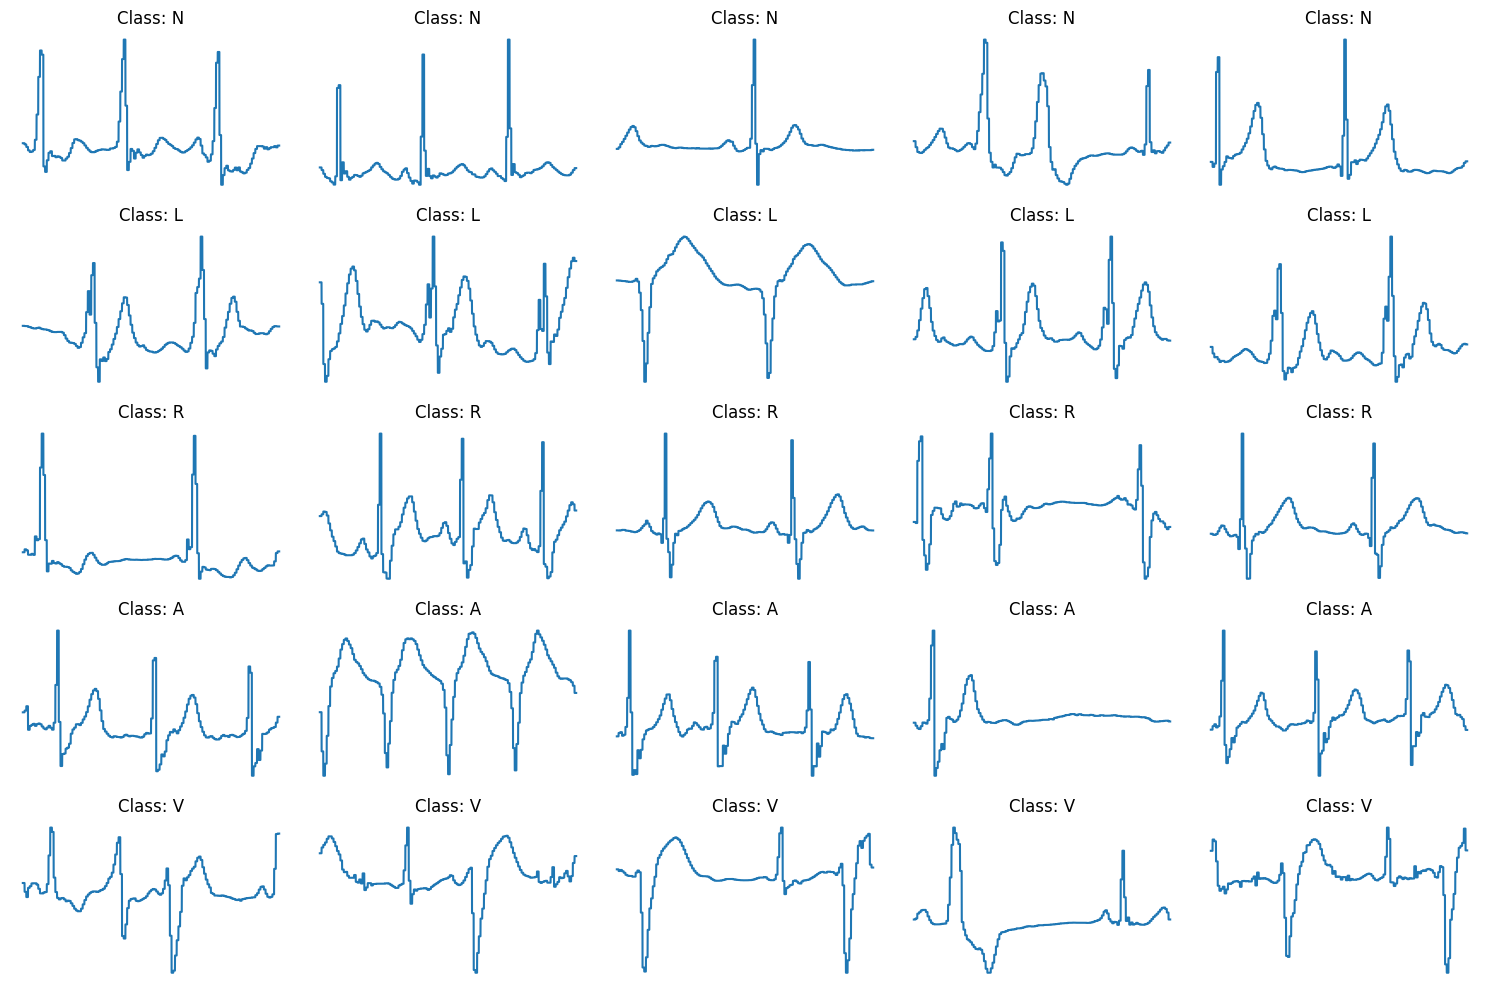

In [ ]:
# Plot the signals after reshaping

label_mapping = {'N': 0, 'L': 1, 'R': 2, 'A': 3, 'V': 4}

def plot_reshaped_signals(X, y, label_mapping, num_examples=5, channel=0):

    reverse_label_mapping = {v: k for k, v in label_mapping.items()}
    unique_labels = np.unique(y)

    plt.figure(figsize=(15, 10))

    for label in unique_labels:
        indices = np.where(y == label)[0]
        for i in range(min(num_examples, len(indices))):
            index = indices[i]
            signal = X[index, :, :, channel].reshape(-1)  # Select the specified channel and flatten to 1D
            plt.subplot(len(unique_labels), num_examples, label * num_examples + i + 1)
            plt.plot(signal)
            plt.title(f"Class: {reverse_label_mapping[label]}")
            plt.axis('off')

    plt.tight_layout()
    plt.show()
# Call the function to plot the signals after reshaping
plot_reshaped_signals(X_train_resized, y_train, label_mapping)


In [ ]:
# Define the InceptionV3 model
height, width, channels = 150, 150, 1
base_model_inception = InceptionV3(weights='imagenet', include_top=False, input_shape=(height, width, 3))
x = base_model_inception.output
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
predictions = Dense(5, activation='softmax')(x)
model_inception = Model(inputs=base_model_inception.input, outputs=predictions)

# Freeze the base model layers
for layer in base_model_inception.layers:
    layer.trainable = False

# Compile the model
model_inception.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
checkpoint_path = '/content/drive/MyDrive/MODElS/inception.h5'
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max')


In [ ]:
# Train the model
history = model_inception.fit(
    X_train_resized, y_train,
    epochs=50,
    validation_data=(X_test_resized, y_test),
    callbacks=[early_stopping, checkpoint]
)

# Evaluate the model
train_accuracy = model_inception.evaluate(X_train_resized, y_train, verbose=0)[1]
test_accuracy = model_inception.evaluate(X_test_resized, y_test, verbose=0)[1]

print(f"Training Accuracy: {train_accuracy}, Test Accuracy: {test_accuracy}")

Epoch 1/50
945/948 [============================>.] - ETA: 0s - loss: 0.3314 - accuracy: 0.8876

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


948/948 [==============================] - 30s 27ms/step - loss: 0.3311 - accuracy: 0.8876 - val_loss: 0.2390 - val_accuracy: 0.9198
Epoch 2/50
948/948 [==============================] - 21s 23ms/step - loss: 0.1841 - accuracy: 0.9360 - val_loss: 0.2035 - val_accuracy: 0.9332
Epoch 3/50
948/948 [==============================] - 18s 19ms/step - loss: 0.1381 - accuracy: 0.9524 - val_loss: 0.2080 - val_accuracy: 0.9343
Epoch 4/50
948/948 [==============================] - 17s 18ms/step - loss: 0.1099 - accuracy: 0.9614 - val_loss: 0.2193 - val_accuracy: 0.9292
Epoch 5/50
948/948 [==============================] - 19s 20ms/step - loss: 0.0882 - accuracy: 0.9679 - val_loss: 0.2129 - val_accuracy: 0.9362
Epoch 6/50
948/948 [==============================] - 19s 20ms/step - loss: 0.0725 - accuracy: 0.9734 - val_loss: 0.2230 - val_accuracy: 0.9386
Epoch 7/50
948/948 [==============================] - 20s 21ms/step - loss: 0.0623 - accuracy: 0.9772 - val_loss: 0.2084 - val_accuracy: 0.9420
Epo

In [ ]:
from tensorflow.keras.models import load_model
# Save and Load the Model
model_path = '/content/drive/MyDrive/MODElS/inception.h5'
loaded_model = load_model(model_path)

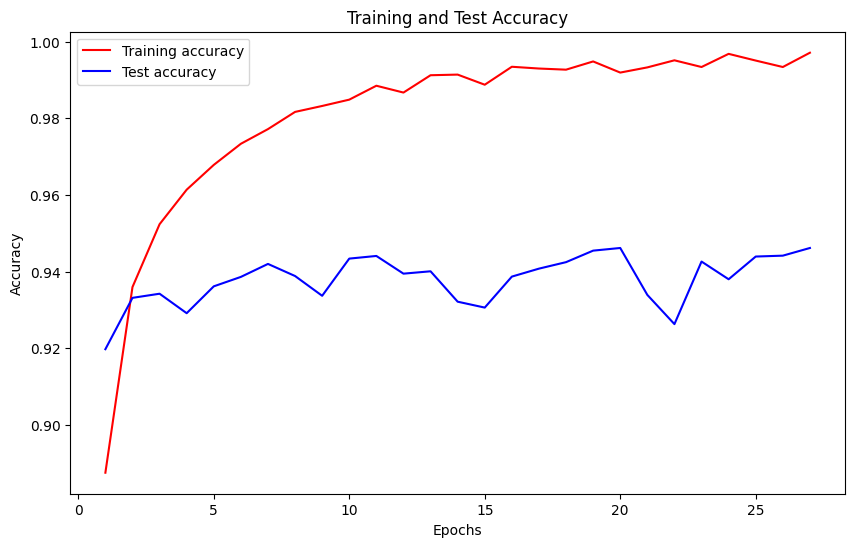

In [ ]:
# Plot training and test accuracies over epochs

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(acc) + 1)  # Number of epochs

plt.figure(figsize=(10, 6))
plt.plot(epochs, acc, 'r', label='Training accuracy')  # 'bo' gives blue color and dot markers
plt.plot(epochs, val_acc, 'b', label='Test accuracy')   # 'b' gives solid blue line
plt.title('Training and Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
# Generate predictions
y_pred = loaded_model.predict(X_test_resized)
y_pred_classes = np.argmax(y_pred, axis=1)

406/406 [==============================] - 5s 10ms/step


In [ ]:
# Print the classification report
class_report = classification_report(y_test, y_pred_classes, target_names=['N', 'L', 'R', 'A', 'V'])
print("\nClassification Report:\n", class_report)


Classification Report:
               precision    recall  f1-score   support

           N       0.97      0.97      0.97     10075
           L       0.92      0.95      0.94       971
           R       0.92      0.94      0.93       976
           A       0.86      0.76      0.81       250
           V       0.74      0.67      0.71       717

    accuracy                           0.95     12989
   macro avg       0.88      0.86      0.87     12989
weighted avg       0.94      0.95      0.95     12989



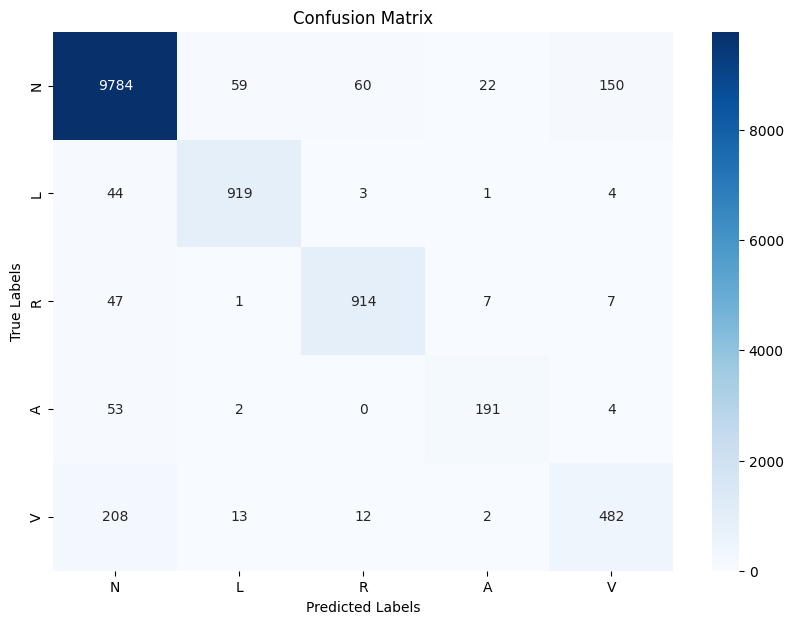

In [ ]:
# Compute and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['N', 'L', 'R', 'A', 'V'], yticklabels=['N', 'L', 'R', 'A', 'V'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

406/406 [==============================] - 4s 10ms/step


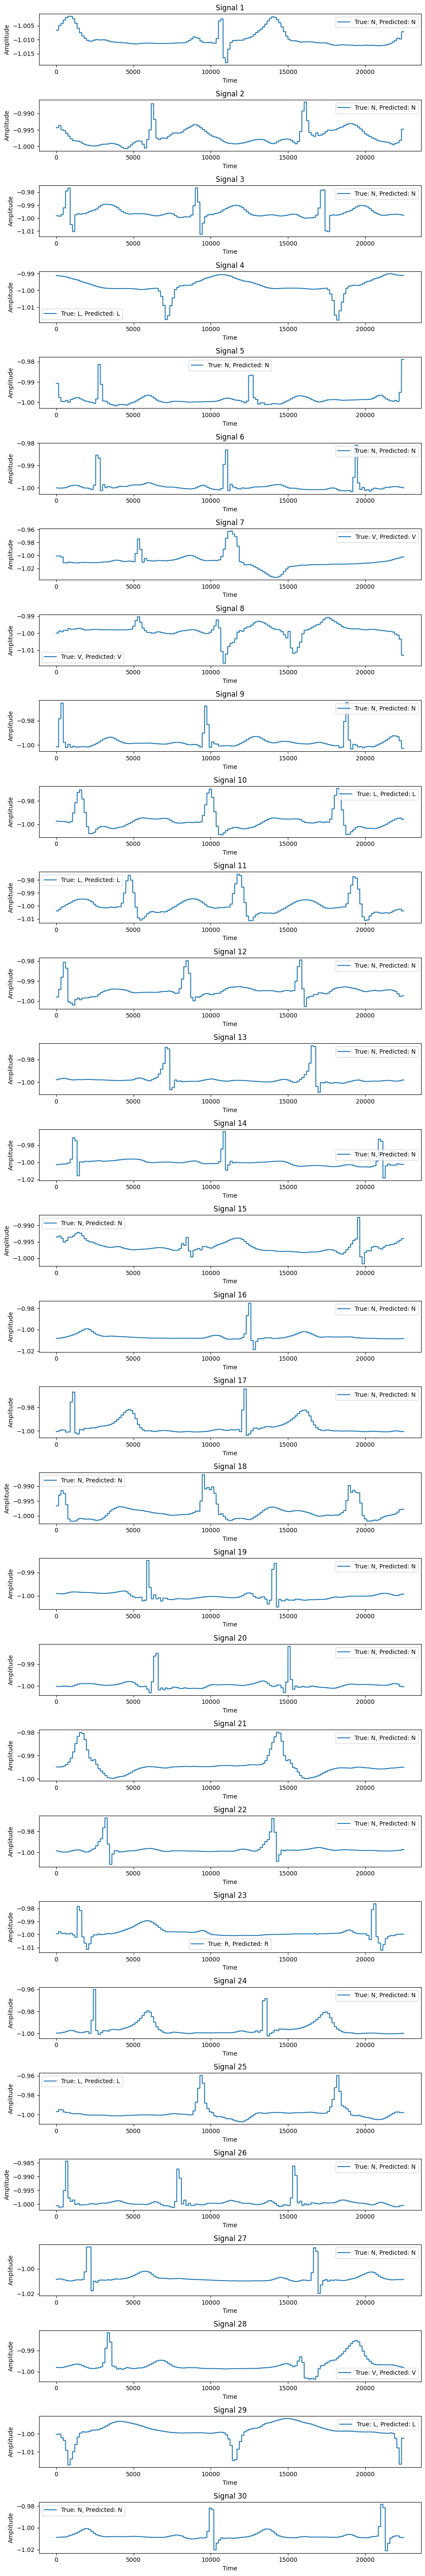

Correct Predictions: 12290
Incorrect Predictions: 699


In [ ]:
# Plot sample signals with true and predicted labels, and display prediction accuracy
def plot_and_predict(X_test, y_test, model, label_mapping, num_samples=10, channel=0):

    # Ensure num_samples does not exceed length of X_test
    num_samples = min(num_samples, len(X_test))

    # Predict the labels
    predictions = model.predict(X_test)
    predicted_labels = np.argmax(predictions, axis=1)

    # Count correct and incorrect predictions
    correct = np.sum(predicted_labels == y_test)
    incorrect = len(y_test) - correct

    # Reverse label mapping
    reverse_label_mapping = {v: k for k, v in label_mapping.items()}

    # Start plotting
    fig, axes = plt.subplots(num_samples, 1, figsize=(10, num_samples * 2))
    if num_samples == 1:
        axes = [axes]  # Make it iterable

    for i, ax in enumerate(axes):
        signal = X_test[i, :, :, channel].flatten()  # Flatten to 1D for plotting
        true_label = reverse_label_mapping[y_test[i]]
        predicted_label = reverse_label_mapping[predicted_labels[i]]
        ax.plot(signal, label=f'True: {true_label}, Predicted: {predicted_label}')
        ax.legend()
        ax.set_title(f'Signal {i+1}')
        ax.set_xlabel('Time')
        ax.set_ylabel('Amplitude')

    plt.tight_layout()
    plt.show()

    print(f"Correct Predictions: {correct}")
    print(f"Incorrect Predictions: {incorrect}")


plot_and_predict(X_test_resized, y_test, loaded_model, label_mapping, num_samples=30)